# Human Interruption Feedback

In [31]:
# import your LLM model
from langchain_ollama import ChatOllama
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image,display,Markdown
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_core.messages import AIMessage,HumanMessage,SystemMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
llm = ChatOllama(model='llama3.1:8b')
results = llm.invoke('Hello my name is Hanif')
print(results)

content='Nice to meet you, Hanif! How are you doing today? Is there something I can help you with or would you like to chat for a bit?' additional_kwargs={} response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-01-02T08:20:02.9546864Z', 'done': True, 'done_reason': 'stop', 'total_duration': 8605235600, 'load_duration': 5963787600, 'prompt_eval_count': 16, 'prompt_eval_duration': 651082400, 'eval_count': 33, 'eval_duration': 1989280000, 'model_name': 'llama3.1:8b'} id='run--912d79b9-0796-454a-83ce-935c6b1a168c-0' usage_metadata={'input_tokens': 16, 'output_tokens': 33, 'total_tokens': 49}


In [26]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper
from langchain_community.tools import TavilySearchResults
from dotenv import load_dotenv
load_dotenv()
import os
tavily_api_key = os.getenv("TAVILY_API_KEY")

In [14]:
print(tavily_api_key)

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


In [29]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=1000)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.invoke('What is the latest research on LLMs?'))

Published: 2016-02-24
Title: Concentration of research funding leads to decreasing marginal returns
Authors: Philippe Mongeon, Christine Brodeur, Catherine Beaudry, Vincent Lariviere
Summary: In most countries, basic research is supported by research councils that select, after peer review, the individuals or teams that are to receive funding. Unfortunately, the number of grants these research councils can allocate is not infinite and, in most cases, a minority of the researchers receive the majority of the funds. However, evidence as to whether this is an optimal way of distributing available funds is mixed. The purpose of this study is to measure the relation between the amount of funding provided to 12,720 researchers in Quebec over a fifteen year period (1998-2012) and their scientific output and impact from 2000 to 2013. Our results show that both in terms of the quantity of papers produced and of their scientific impact, the concentration of research funding in the hands of a so-

In [27]:
api_wrapper_wikipedia = WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=10000)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia)
print(wiki.invoke('Prabowo Subianto'))

Page: Prabowo Subianto
Summary: Prabowo Subianto Djojohadikusumo (born 17 October 1951) is an Indonesian politician, businessman, and retired military officer who has served as the eighth president of Indonesia since 2024. He previously served as the 26th minister of defense under President Joko Widodo from 2019 to 2024. Prabowo is Indonesia's third president to have a military background after Suharto and Susilo Bambang Yudhoyono and is the oldest first-term president in Indonesian history.
Prabowo graduated from the Indonesian Military Academy in 1970 and primarily served in the Special Forces (Kopassus) until he was appointed to lead the Strategic Reserves Command (Kostrad) in 1998. Later that same year, he was discharged from the military and subsequently banned from entering the United States for allegedly committing human rights abuses.
In early 2008, Prabowo's inner circle established the Gerindra Party. In the 2009 presidential election, he ran unsuccessfully for the vice presi

In [28]:
tavily_search_engine = TavilySearchResults(tavily_api_key=tavily_api_key,top_k=2)
tavily_search_engine.invoke('What is the lastest news AI LLM?')

[{'title': 'LLM News Today | AI News & Latest Model Announcements',
  'url': 'https://llm-stats.com/ai-news',
  'content': "AI News =======AI TrendsLLM Updates\n\nLLM News Today\n\nYour daily source for LLM news andAI news. Breaking announcements, new model releases, benchmark results, and the latest headlines from the AI industry.\n\nLLM Leaderboard•Benchmark News•Community Discussions•New LLM Releases\n\n   LLM News\n   New Releases\n   Open Source\n   Benchmarks\n   Resources\n   FAQ\n\nLLM Update News\n\nFrom AI labs, research & community\n\nLive\n\nToday [...] LLM Stats aggregates the latest large language model updates from major AI labs including OpenAI, Anthropic, Google, Meta, and others. Our news feed is updated hourly with new model releases, benchmark results, and AI research announcements. Check theLLM Update Newssection above for today's headlines.\n\n### Where can I find open source LLM news today? [...] Sebastian CrossaSebastian Crossa Dec 15, 2025",
  'score': 0.769929

In [30]:
tools = [arxiv,wiki,tavily_search_engine]
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

RunnableBinding(bound=ChatOllama(model='llama3.1:8b'), kwargs={'tools': [{'type': 'function', 'function': {'name': 'arxiv', 'description': 'A wrapper around Arxiv.org Useful for when you need to answer questions about Physics, Mathematics, Computer Science, Quantitative Biology, Quantitative Finance, Statistics, Electrical Engineering, and Economics from scientific articles on arxiv.org. Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'search query to look up', 'type': 'string'}}, 'required': ['query'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'wikipedia', 'description': 'A wrapper around Wikipedia. Useful for when you need to answer general questions about people, places, companies, facts, historical events, or other subjects. Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'query to look up on wikipedia', 'type': 'string'}}, 'required': ['query'], 'type': 'object'}}}, {'type': 'fun

In [62]:
# Workflow with LangGraph
sys_message = SystemMessage(content = "You are assitant for AI Developer to build LLM integrate with application to support Business needs.")

def assistant(state:MessagesState):
    return {"messages":[llm_with_tools.invoke([sys_message]+ state["messages"])]}

builder = StateGraph(MessagesState)

builder.add_node("assistant",assistant)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"assistant")
builder.add_conditional_edges("assistant",tools_condition)

builder.add_edge("tools","assistant")

memory = MemorySaver()

graph = builder.compile(interrupt_before = ["assistant"],checkpointer = memory)



In [63]:
mermaid_code = graph.get_graph().draw_mermaid()
with open("human_interrupt_loop.mmd", "w") as f:
    f.write(mermaid_code)

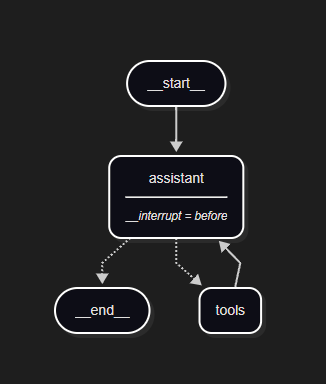

In [64]:
thread_id = {"configurable" : {"thread_id":"1"}}
initial_input = {"messages":[HumanMessage(content="Who is Sam Altmaan?")]}

In [65]:
for event in graph.stream(initial_input, thread_id,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Who is Sam Altmaan?


In [ ]:
# check the next state in current thread
state = graph.get_state(thread_id)
state.next

('assistant',)

In [46]:
state

StateSnapshot(values={'messages': [HumanMessage(content='Who is Sam Altmaan?}', additional_kwargs={}, response_metadata={}, id='50f03195-e722-4e25-b7a7-4e8f6783f02a')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e7b54-ee07-6b5c-8000-8c20a4554471'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}, 'thread_id': '1'}, created_at='2026-01-02T08:30:34.691670+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0e7b54-edfd-695b-bfff-754eb63b3887'}}, tasks=(PregelTask(id='f5003ff1-5bf5-bad3-bdb4-922d2b260aa6', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [66]:
#continue the execution
for event in graph.stream(None, thread_id,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Who is Sam Altmaan?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (5c920096-4d5d-4789-8c20-377060cbd385)
 Call ID: 5c920096-4d5d-4789-8c20-377060cbd385
  Args:
    query: Sam Altman
================================= Tool Message =================================
Name: wikipedia

Page: Sam Altman
Summary: Samuel Harris Altman (born April 22, 1985) is an American entrepreneur, investor, and chief executive officer of OpenAI since 2019. He is considered one of the leading figures of the AI boom.
Altman dropped out of Stanford University after two years and founded Loopt, a mobile social networking service, raising more than $30 million in venture capital. In 2011, Altman joined Y Combinator, a startup accelerator, and was its president from 2014 to 2019. In 2019, he became CEO of OpenAI and oversaw the successful launch of ChatGPT in 2022. He was ous

In [68]:
state = graph.get_state(thread_id)
state.next

('assistant',)

In [69]:
#continue the execution
for event in graph.stream(None, thread_id,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: wikipedia

Page: Sam Altman
Summary: Samuel Harris Altman (born April 22, 1985) is an American entrepreneur, investor, and chief executive officer of OpenAI since 2019. He is considered one of the leading figures of the AI boom.
Altman dropped out of Stanford University after two years and founded Loopt, a mobile social networking service, raising more than $30 million in venture capital. In 2011, Altman joined Y Combinator, a startup accelerator, and was its president from 2014 to 2019. In 2019, he became CEO of OpenAI and oversaw the successful launch of ChatGPT in 2022. He was ousted from the role by the company's board in 2023 due to a lack of confidence in his leadership, but was reinstated five days later following significant backlash from employees and investors, after which a new board was formed. He has served as chairman of clean energy companies Helion Energy and Oklo (until April 2025). 

In [70]:
state = graph.get_state(thread_id)
state.next

()

## Edit with Human Feedback

In [78]:
thread_id = {"configurable" : {"thread_id":"3"}}
initial_input = {"messages":[HumanMessage(content="Who is Sam Altmaan?")]}

for event in graph.stream(initial_input, thread_id,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Who is Sam Altmaan?


In [79]:
graph.update_state(thread_id,{"messages":[HumanMessage(content = 'Please change to Elon Musk')]})

{'configurable': {'thread_id': '3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0e7bb9-7541-681c-8001-ae5f8bf6943d'}}

In [80]:
new_state = graph.get_state(thread_id).values
for m in new_state['messages']:
    m.pretty_print()

================================ Human Message =================================

Who is Sam Altmaan?
================================ Human Message =================================

Please change to Elon Musk


In [81]:
for event in graph.stream(None, thread_id,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Please change to Elon Musk
================================== Ai Message ==================================
Tool Calls:
  wikipedia (a50aa315-f65d-42f4-ace7-bd3b188bd6a9)
 Call ID: a50aa315-f65d-42f4-ace7-bd3b188bd6a9
  Args:
    query: Elon Musk
================================= Tool Message =================================
Name: wikipedia

Page: Elon Musk
Summary: Elon Reeve Musk ( EE-lon; born June 28, 1971) is a businessman and entrepreneur known for his leadership of Tesla, SpaceX, X, and xAI. Musk has been the wealthiest person in the world since 2021; as of December 2025, Forbes estimates his net worth to be around US$754 billion.
Born into a wealthy family in Pretoria, South Africa, Musk emigrated in 1989 to Canada; he has Canadian citizenship since his mother was born there. He received bachelor's degrees in 1997 from the University of Pennsylvania in Philadelphia, United States, before moving t

In [82]:
state = graph.get_state(thread_id)
state.next

('assistant',)